In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import lcmv_xtra

# --- Paths ---
subject_dir = Path("/mnt/movement/users/jaizor/xtra/derivatives/lcmv/sub-01_rest_off_c")
difumo_file = subject_dir / "difumo_time_courses.npy"
gt_file = subject_dir / "gt_time_courses.npy"
output_file = subject_dir / "gpi_stn_time_series.npy"

# --- Load data ---
difumo_tc = np.load(difumo_file)  # (512, n_time)
gt_tc = np.load(gt_file)          # (414, n_time) ← confirmed by your error

# Validate shapes
assert difumo_tc.shape[0] == 512, f"DiFuMo shape mismatch: {difumo_tc.shape}"
assert gt_tc.shape[0] == 414, f"GT shape mismatch: {gt_tc.shape}"

# --- Load GT labels ---
package_dir = Path(lcmv_xtra.__file__).parent
roi_file = package_dir / 'data' / 'gt_atlas' / 'roi_labels.csv'
roi_df = pd.read_csv(roi_file)
gt_labels = roi_df['roi_name'].tolist()
assert len(gt_labels) == 414, "Label count mismatch"

# --- Find indices ---
idx_lgpi = gt_labels.index('pGP-lh')
idx_rgpi = gt_labels.index('pGP-rh')

# --- Extract time series (all are 1D arrays of length n_time) ---
stn_ts = difumo_tc[223, :]      # (n_time,)
gpi_lh_ts = gt_tc[idx_lgpi, :]  # (n_time,)
gpi_rh_ts = gt_tc[idx_rgpi, :]  # (n_time,)

# Stack into (n_time, 3)
gpi_stn_ts = np.column_stack([gpi_lh_ts, gpi_rh_ts, stn_ts])

# Save
np.save(output_file, gpi_stn_ts)
print(f"Success! Saved shape: {gpi_stn_ts.shape} to {output_file}")

Success! Saved shape: (30002, 3) to /mnt/movement/users/jaizor/xtra/derivatives/lcmv/sub-01_rest_off_c/gpi_stn_time_series.npy


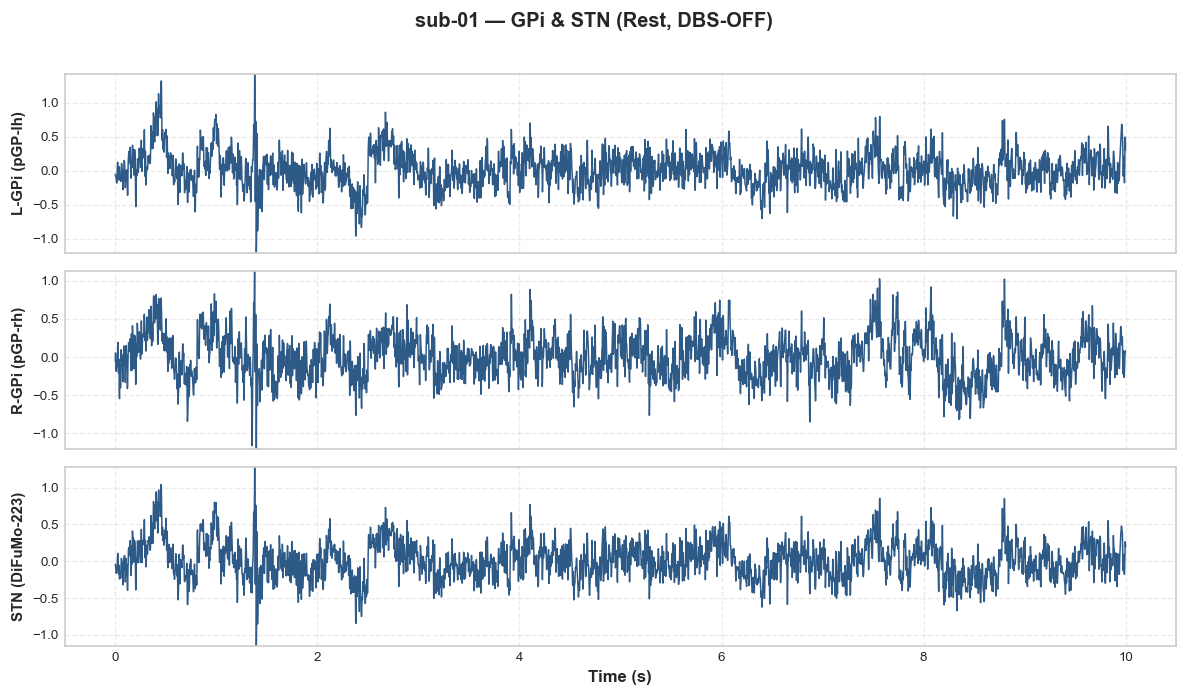

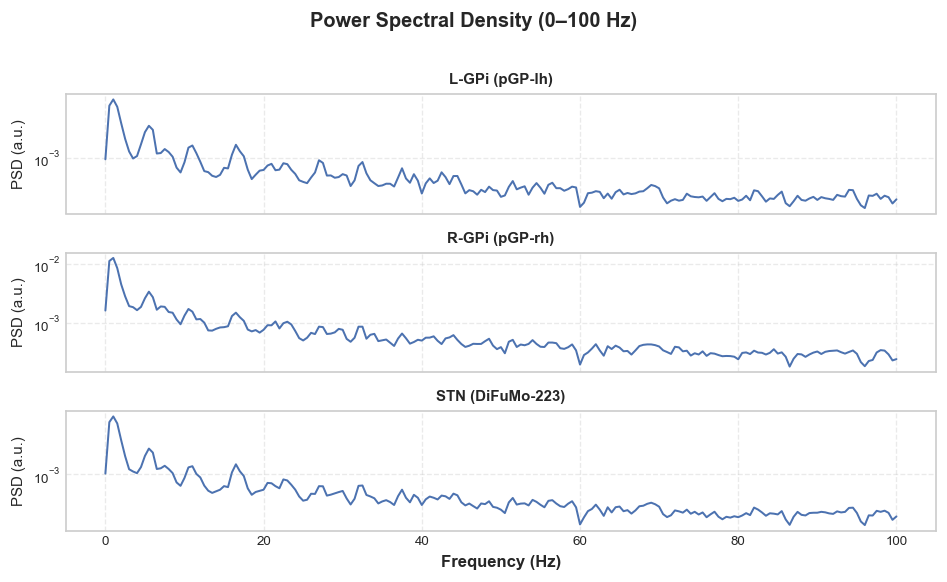


🔬 Integrated Beta Band Power (13–30 Hz):
  L-GPi (pGP-lh)      : 1.194e-02 (a.u.)
  R-GPi (pGP-rh)      : 1.408e-02 (a.u.)
  STN (DiFuMo-223)    : 1.075e-02 (a.u.)


In [10]:
# Visualize regions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import lcmv_xtra
from scipy.signal import welch
from scipy.integrate import trapezoid


def plot_gpi_stn_time_series(
    subject_dir: Path,
    duration_sec: float = 60.0,
    sfreq: float = 500.0,
    title: str = "GPi & STN Source Time Series (DBS-OFF Rest)"
):
    """
    Load and plot GPi (L/R) and STN time series from LCMV source reconstruction.
    
    Parameters
    ----------
    subject_dir : Path
        Directory containing 'difumo_time_courses.npy' and 'gt_time_courses.npy'
    duration_sec : float
        Duration (in seconds) of raw trace to display
    sfreq : float
        Sampling frequency in Hz (default: 500 Hz)
    title : str
        Plot title
    """
    # --- Load data ---
    difumo_tc = np.load(subject_dir / "difumo_time_courses.npy")  # (512, n_time)
    gt_tc = np.load(subject_dir / "gt_time_courses.npy")          # (414, n_time)

    assert difumo_tc.shape[0] == 512, f"DiFuMo shape mismatch: {difumo_tc.shape}"
    assert gt_tc.shape[0] == 414, f"GT shape mismatch: {gt_tc.shape}"

    # --- Load GT labels ---
    package_dir = Path(lcmv_xtra.__file__).parent
    roi_file = package_dir / 'data' / 'gt_atlas' / 'roi_labels.csv'
    roi_df = pd.read_csv(roi_file)
    gt_labels = roi_df['roi_name'].tolist()
    assert len(gt_labels) == 414

    # --- Extract regions ---
    stn_ts = difumo_tc[223, :]
    gpi_lh_ts = gt_tc[gt_labels.index('pGP-lh'), :]
    gpi_rh_ts = gt_tc[gt_labels.index('pGP-rh'), :]

    # Combine
    data = np.vstack([gpi_lh_ts, gpi_rh_ts, stn_ts])  # (3, n_time)
    ch_names = ['L-GPi (pGP-lh)', 'R-GPi (pGP-rh)', 'STN (DiFuMo-223)']
    n_time = data.shape[1]
    times = np.arange(n_time) / sfreq

    # --- Trim to requested duration ---
    n_samples = int(duration_sec * sfreq)
    if n_samples > n_time:
        n_samples = n_time
        print(f"⚠️ Requested duration ({duration_sec}s) exceeds data length. Plotting full {n_time/sfreq:.1f}s.")

    data_plot = data[:, :n_samples]
    times_plot = times[:n_samples]

    # --- Plot raw traces ---
    plt.style.use('seaborn-v0_8-whitegrid')  # clean background
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, dpi=120)
    trace_color = '#2E5A88'

    for i, (ax, ch) in enumerate(zip(axes, ch_names)):
        ax.plot(times_plot, data_plot[i], color=trace_color, linewidth=0.9)
        ax.set_ylabel(ch, fontsize=9, fontweight='bold')
        ax.set_ylim(data_plot[i].min(), data_plot[i].max())
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)

    axes[-1].set_xlabel("Time (s)", fontsize=10, fontweight='bold')
    fig.suptitle(title, fontsize=12, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # --- Power Spectral Density (PSD) ---
    fig2, axes2 = plt.subplots(3, 1, figsize=(8, 5), sharex=True, dpi=120)
    fmax = 100
    psd_color = '#4C72B0'

    for i, (ax, ch) in enumerate(zip(axes2, ch_names)):
        f, psd = welch(data[i], fs=sfreq, nperseg=int(sfreq * 2), noverlap=int(sfreq))
        mask = f <= fmax
        ax.semilogy(f[mask], psd[mask], color=psd_color, linewidth=1.2)
        ax.set_ylabel("PSD (a.u.)", fontsize=9)
        ax.set_title(ch, fontsize=9, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(axis='both', which='major', labelsize=8)

    axes2[-1].set_xlabel("Frequency (Hz)", fontsize=10, fontweight='bold')
    fig2.suptitle(f"Power Spectral Density (0–{fmax} Hz)", fontsize=12, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # --- Beta power summary (13–30 Hz) ---
    print("\n🔬 Integrated Beta Band Power (13–30 Hz):")
    for i, ch in enumerate(ch_names):
        f, psd = welch(data[i], fs=sfreq, nperseg=int(sfreq * 2))
        beta_mask = (f >= 13) & (f <= 30)
        if np.any(beta_mask):
            beta_power = trapezoid(psd[beta_mask], f[beta_mask])
        else:
            beta_power = 0.0
        print(f"  {ch:20s}: {beta_power:.3e} (a.u.)")


# --- Example usage ---
if __name__ == "__main__":
    subject_dir = Path("/mnt/movement/users/jaizor/xtra/derivatives/lcmv/sub-01_rest_off_c")
    plot_gpi_stn_time_series(
        subject_dir=subject_dir,
        duration_sec=10.0,
        sfreq=500.0,
        title="sub-01 — GPi & STN (Rest, DBS-OFF)"
    )